(mmm_discounted_events)=
# Optimising Discount Depth Across Promotional Events

Brands and marketplaces run promotions — Black Friday, summer sales, back-to-school — where the key question is not *whether* to promote but *how deeply* to discount.

Discount depth involves a fundamental trade-off: deeper discounts attract more volume, but each unit sold generates less revenue, and a fraction of the existing customer base's spend is redirected into the discount.  This trade-off is captured by a **full revenue-retention model**:

$$\text{lift}_k = \beta_k \cdot \ln(1 + d_k) \cdot (1 - d_k) - d_k \cdot r_k$$

where $d_k$ is the discount percentage for event $k$, $\beta_k$ is a per-event coefficient learned from observed revenue, and $r_k$ is the average baseline revenue per in-sample period during event $k$ (automatically computed from the observed target).

- $\ln(1 + d_k)$ models **volume uplift** — more customers buy at deeper discounts, with diminishing returns.
- $(1 - d_k)$ models **price retention** — at 100 % discount you collect nothing per unit.
- $-d_k \cdot r_k$ models the **margin cost** — a fraction $d_k$ of the existing customer base's spend is forgone as a discount.

Together they produce a **hump-shaped curve**: lift is zero at $d = 0$ (no discount, no effect), rises to an interior optimum, then falls and eventually becomes negative — at $d = 1$ the cost term $-r_k$ dominates, driving total per-period revenue to zero.  The optimal depth shifts with the $r_k / \beta_k$ ratio: events with large $\beta_k$ relative to $r_k$ favour deeper discounts.

This notebook demonstrates `DiscountedEventEffect`, which implements this model and integrates with `BudgetOptimizer` so discount budgets are allocated jointly with paid media channels from a **shared budget pool**.

**Key ideas**

- Promotional event windows (date ranges) are fixed and known in advance.
- The optimisation lever is *how much to discount* each event, expressed as a fraction of the event revenue at stake.
- $\beta_k$ is learned from the data — no user-supplied revenue baseline is needed; $r_k$ is computed automatically from the observed target.
- Paid media channels and promotional events share the same total budget constraint.


## Setup

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from pymc_marketing.mmm import MMM, BudgetOptimizerWrapper, DiscountedEventEffect
from pymc_marketing.mmm.budget_optimizer import BudgetOptimizer
from pymc_marketing.mmm.components.adstock import GeometricAdstock
from pymc_marketing.mmm.components.saturation import LogisticSaturation

warnings.filterwarnings("ignore")

seed = sum(map(ord, "mmm_discounted_events"))
rng = np.random.default_rng(seed)

/Users/pablo.deroqueglovoapp.com/mamba/envs/pymc-marketing-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic data

We generate one year of weekly revenue with two paid media channels and three promotional
event windows.  The ground-truth lift during each event follows
$\text{TRUE\_BETA}_k \cdot \ln(1 + d_k) \cdot (1 - d_k) - d_k \cdot r_k$,
consistent with the forward model.  Here $r_k$ is the average baseline revenue per
in-sample period during event $k$.

The combined formula is hump-shaped: the net lift peaks at a discount depth that
depends on the $r_k / \text{TRUE\_BETA}_k$ ratio — shallower for events where the
baseline revenue cost is large relative to the volume-uplift coefficient.
TRUE_BETA is set large enough that the historical discount depths (10–20 %) still
produce positive, observable lifts well to the left of the peak.


In [27]:
rng = np.random.default_rng(seed)  # reset so DGP is reproducible on re-run

n_weeks = 52
dates = pd.date_range("2024-01-01", periods=n_weeks, freq="W")

# ── Paid media spend ─────────────────────────────────────────────────────────
df = pd.DataFrame(
    {
        "date_week": dates,
        "social": rng.gamma(shape=2, scale=50, size=n_weeks),
        "search": rng.gamma(shape=2, scale=30, size=n_weeks),
    }
)

# ── Promotional events ───────────────────────────────────────────────────────
# discount_pct : historical fraction of event revenue given away as discount
df_events = pd.DataFrame(
    {
        "name": ["black_friday", "summer_sale", "back_to_school"],
        "start_date": ["2024-11-25", "2024-07-01", "2024-08-26"],
        "end_date": ["2024-12-01", "2024-07-07", "2024-09-01"],
        "discount_pct": [0.20, 0.15, 0.10],
    }
)

# ── Ground-truth revenue ─────────────────────────────────────────────────────
# TRUE_BETA is the volume-uplift coefficient (€ / week) per unit of ln(1+d).
# Positive values mean the promotion is net-profitable at the historical depth.
# Values are set so that black_friday > summer_sale > back_to_school.
TRUE_BETA = {"black_friday": 5_000.0, "summer_sale": 3_000.0, "back_to_school": 2_000.0}

# Baseline revenue (no promo effects) — used to compute r_k for each event.
baseline = 500.0 + 0.2 * df["search"] + 0.3 * df["social"]
weekly_revenue = baseline.copy()

for _, row in df_events.iterrows():
    mask = (dates >= pd.Timestamp(row["start_date"])) & (
        dates <= pd.Timestamp(row["end_date"])
    )
    d = row["discount_pct"]
    r_k = float(baseline[mask].mean())  # avg baseline revenue per period (event k)
    weekly_revenue[mask] += TRUE_BETA[row["name"]] * np.log1p(d) * (1 - d) - d * r_k

y = pd.Series(
    weekly_revenue.values + rng.normal(0, 20, n_weeks),
    name="y",
)

df.head()

,date_week,social,search
0,2024-01-07,177.151680,137.721904
1,2024-01-14,152.646805,84.375113
2,2024-01-21,40.394697,113.187162
3,2024-01-28,148.193484,59.844295
4,2024-02-04,82.970766,93.515902


Let's quickly visualise revenue to confirm the event windows are visible:

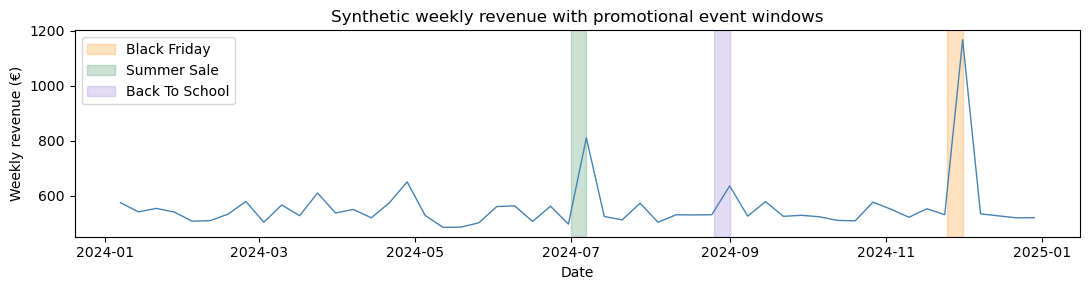

In [28]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(dates, y, lw=1, color="steelblue")

event_colors = ["darkorange", "seagreen", "mediumpurple"]
for (_, row), color in zip(df_events.iterrows(), event_colors, strict=False):
    ax.axvspan(
        pd.Timestamp(row["start_date"]),
        pd.Timestamp(row["end_date"]),
        alpha=0.25,
        color=color,
        label=row["name"].replace("_", " ").title(),
    )

ax.set_xlabel("Date")
ax.set_ylabel("Weekly revenue (€)")
ax.set_title("Synthetic weekly revenue with promotional event windows")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Define `DiscountedEventEffect`

`DiscountedEventEffect` requires only the event windows and historical discount
percentages.  A per-event `beta_prior` — defaulting to `HalfNormal(σ=1)` — is placed on
$\beta_k$.  The prior can be overridden per instantiation if domain knowledge is available.

In [29]:
# Prescription bounds — set once at construction so BudgetOptimizer
# picks them up via DiscountedEventEffect.budget_bounds.
D_MIN = 0.10  # minimum allowed discount percentage
D_MAX = 0.35  # maximum allowed discount percentage
STEP = 0.05  # prescription granularity
GRID = np.arange(D_MIN, D_MAX + 1e-9, STEP)  # [0.10, 0.15, …, 0.35]

effect = DiscountedEventEffect(
    df_events=df_events,
    prefix="promo",
    discount_min=D_MIN,
    discount_max=D_MAX,
    # Override the default HalfNormal(sigma=1) if needed:
    # from pymc_extras.prior import Prior
    # beta_prior=Prior("HalfNormal", sigma=2),
)

print("Event names (budget_dim)  :", list(effect.df_events["name"]))
print("Budget dimension          :", effect.budget_dim)
print("Contribution variable     :", effect.contribution_var_name)

Event names (budget_dim)  : ['black_friday', 'summer_sale', 'back_to_school']
Budget dimension          : promo
Contribution variable     : promo_effect_contribution


## Build and fit the MMM

The effect is attached to a standard `MMM` with two paid media channels.  After
`add_mu_effect`, the model has one additional free parameter per event: `promo_beta`.

In [30]:
mmm = MMM(
    adstock=GeometricAdstock(l_max=2),
    saturation=LogisticSaturation(),
    date_column="date_week",
    channel_columns=["search", "social"],
)
mmm.add_mu_effect(effect)
mmm.build_model(X=df, y=y)

# Show the free RVs — promo_beta should appear once per event
print("Free RVs:", [rv.name for rv in mmm.model.free_RVs])

Free RVs: ['intercept_contribution', 'adstock_alpha', 'saturation_lam', 'saturation_beta', 'promo_beta', 'y_sigma']


In [31]:
idata = mmm.fit(
    X=df,
    y=y,
    target_accept=0.9,
    chains=4,
    draws=500,
    tune=500,
    random_seed=rng,
    progressbar=True,
    nuts_sampler="nutpie",
    nuts_sampler_kwargs={"backend": "jax", "gradient_backend": "jax"},
)
mmm.add_original_scale_contribution_variable(
    ["channel_contribution", "promo_channel_contribution"]
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.21,15
,1000,0,0.18,31
,1000,0,0.20,31
,1000,0,0.20,15


In [32]:
az.summary(idata, var_names=["promo_beta"]).round(3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
promo_beta[black_friday],5.109,0.108,4.907,5.316,0.002,0.002,2136.0,1364.0,1.0
promo_beta[summer_sale],2.785,0.136,2.533,3.037,0.003,0.003,2387.0,1485.0,1.0
promo_beta[back_to_school],1.674,0.185,1.325,2.010,0.004,0.004,1975.0,948.0,1.0


## Posterior lift curves

Each event's lift curve is
$\beta_k \cdot \ln(1 + d) \cdot (1 - d) \cdot \text{target\_scale} - d \cdot r_k$
evaluated over the full discount range $[0, 1]$.  The posterior uncertainty of $\beta_k$ is propagated through the curve, giving a 94 % HDI band.  Dashed vertical lines mark the historical discount depth.

The curves are **hump-shaped**: lift is zero at $d = 0$ (no discount, no effect),
rises to an interior peak, then falls and eventually turns negative at high discount depths where the $-d \cdot r_k$ baseline-cost term dominates.  The peak depth shifts with the $r_k / \beta_k$ ratio — events with large volume-uplift coefficients relative to their baseline revenue favour deeper discounts.  The historical depths (10–20 %) sit well to the left of each peak, indicating room to increase discount depth to capture more lift.

:::{note}
The dashed vertical lines show the historical discount depth for each event, not the model-recommended depth.  The optimizer (next section) finds the depth that maximises net revenue across all channels jointly under the shared budget constraint.
:::


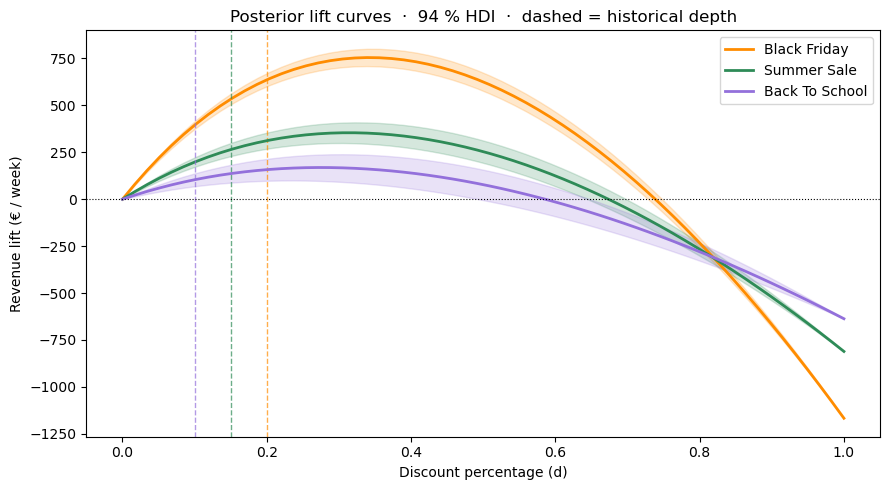

In [33]:
beta_da = idata.posterior["promo_beta"]  # DataArray (chain, draw, promo)
target_scale = float(idata.constant_data["target_scale"].squeeze())  # un-normalise beta
discount_grid = np.linspace(0, 1, 60)  # discount_pct axis
log_vol_ret = np.log1p(discount_grid) * (1 - discount_grid)  # ln(1+d)·(1-d)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["darkorange", "seagreen", "mediumpurple"]

for event_idx, (color, event_name) in enumerate(
    zip(colors, df_events["name"], strict=False)
):
    beta_samples = beta_da.sel(promo=event_name).values.ravel()  # (chain * draw,)
    r_per_period = effect._revenue_per_period[event_idx]  # baseline rev/period (€)

    # Lift in original scale:
    #   β·ln(1+d)·(1-d)·target_scale  — hump-shaped volume x price-retention
    #   -d·r_per_period               — baseline cost (margin forgone per period)
    lift = (
        beta_samples[:, None] * log_vol_ret[None, :] * target_scale
        - discount_grid[None, :] * r_per_period
    )  # shape (n_samples, n_points)
    lift_mean = lift.mean(axis=0)
    lift_hdi = az.hdi(lift, hdi_prob=0.94)  # (n_points, 2)

    label = event_name.replace("_", " ").title()
    ax.plot(discount_grid, lift_mean, color=color, label=label, lw=2)
    ax.fill_between(
        discount_grid,
        lift_hdi[:, 0],
        lift_hdi[:, 1],
        alpha=0.2,
        color=color,
    )

    hist_pct = float(
        df_events.loc[df_events["name"] == event_name, "discount_pct"].iloc[0]
    )
    ax.axvline(hist_pct, color=color, ls="--", lw=1, alpha=0.7)

ax.axhline(0, color="black", lw=0.8, ls=":")
ax.set_xlabel("Discount percentage (d)")
ax.set_ylabel("Revenue lift (€ / week)")
ax.set_title("Posterior lift curves  ·  94 % HDI  ·  dashed = historical depth")
ax.legend()
plt.tight_layout()
plt.show()

## Optimise discount allocation

`BudgetOptimizer` allocates a single budget pool across all channels — paid media and
promotional events — simultaneously.  Each euro sent to an event is converted to a discount percentage via
`discount_pct = budget / event_revenue`, where `event_revenue` is automatically
computed from the observed target `y` over each event's date window.  The optimizer
naturally trades off media spend against discount depth.

In [34]:
wrapper = BudgetOptimizerWrapper(
    model=mmm,
    start_date="2024-06-01",
    end_date="2024-12-31",
)
optimizer = BudgetOptimizer(model=wrapper, num_periods=wrapper.num_periods)

# ── Derive total_budget from current spend so the comparison is apples-to-apples
opt_mask = (df["date_week"] >= pd.Timestamp(wrapper.start_date)) & (
    df["date_week"] <= pd.Timestamp(wrapper.end_date)
)
current_media = {col: float(df.loc[opt_mask, col].sum()) for col in mmm.channel_columns}
current_events = {
    name: float(pct * rev)
    for name, pct, rev in zip(
        df_events["name"],
        df_events["discount_pct"],
        effect._event_revenue,
        strict=False,
    )
}
total_budget = sum(current_media.values()) + sum(current_events.values())

optimal, result = optimizer.allocate_budget(
    total_budget=total_budget,
    budget_bounds={col: (0.0, total_budget) for col in mmm.channel_columns},
)

print(f"Total current spend  : {total_budget:.2f}")
print(f"Optimisation success : {result.success}")
print(f"Total allocated      : {optimal.values.sum():.2f} / {total_budget:.2f}")
print()
print(optimal.to_series().rename("optimal_budget (€)").to_frame().round(1))

Total current spend  : 4927.84
Optimisation success : True
Total allocated      : 4927.84 / 4927.84

                optimal_budget (€)
channel                           
search                       445.4
social                      3809.1
black_friday                 341.1
summer_sale                  205.0
back_to_school               127.2


The `channel_type` attribute on the result labels each entry as `media` or `event`:

In [35]:
print("channel_type attrs:", optimal.attrs.get("channel_type", {}))

channel_type attrs: {'search': 'media', 'social': 'media', 'black_friday': 'effect', 'summer_sale': 'effect', 'back_to_school': 'effect'}


## Compare current vs optimal

For media channels the *current* budget is historical spend during the optimisation
window.  For events it is the implied discount cost at the historical depth:
`discount_pct × event_revenue` (where `event_revenue` is computed from `y`).

In [36]:
# ── Build current-allocation DataArray (variables set in the optimizer cell) ──
current_dict = {**current_media, **current_events}

channels_order = optimal.coords["channel"].values
current = xr.DataArray(
    [current_dict.get(ch, 0.0) for ch in channels_order],
    coords={"channel": channels_order},
    dims=["channel"],
)

# ── Summary table ─────────────────────────────────────────────────────────────
df_cmp = pd.DataFrame(
    {"current": current.values, "optimal": optimal.values},
    index=channels_order,
)
df_cmp["delta"] = df_cmp["optimal"] - df_cmp["current"]
df_cmp["delta_pct"] = df_cmp["delta"] / df_cmp["current"].replace(0, float("nan")) * 100
print(df_cmp.round(1))

                current  optimal   delta  delta_pct
search           1882.3    445.4 -1436.9      -76.3
social           2626.8   3809.1  1182.4       45.0
black_friday      233.4    341.1   107.7       46.2
summer_sale       121.7    205.0    83.3       68.5
back_to_school     63.7    127.2    63.5       99.7


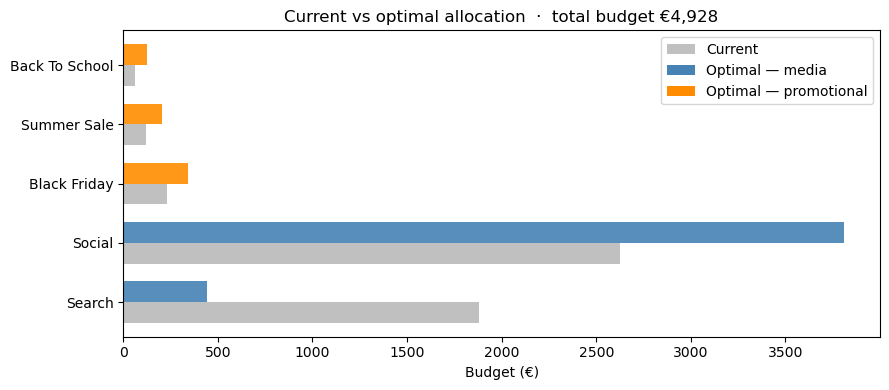

In [37]:
from matplotlib.patches import Patch

event_names = set(df_events["name"])
bar_colors = [
    "darkorange" if ch in event_names else "steelblue" for ch in channels_order
]

x = np.arange(len(channels_order))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(x - w / 2, df_cmp["current"], w, color="silver", label="Current")
ax.barh(x + w / 2, df_cmp["optimal"], w, color=bar_colors, label="Optimal", alpha=0.9)
ax.set_yticks(x)
ax.set_yticklabels([c.replace("_", " ").title() for c in channels_order])
ax.set_xlabel("Budget (€)")
ax.set_title(f"Current vs optimal allocation  ·  total budget €{total_budget:,.0f}")
ax.legend(
    handles=[
        Patch(facecolor="silver", label="Current"),
        Patch(facecolor="steelblue", label="Optimal — media"),
        Patch(facecolor="darkorange", label="Optimal — promotional"),
    ]
)
plt.tight_layout()
plt.show()

## Discount prescription — 5 % steps between 10 % and 35 %

Promotional events often need operationally enforceable, round-number discount
settings (e.g. a pricing system that accepts only multiples of 5 %).  The
`[D_MIN, D_MAX]` bounds were already enforced by the optimizer above via
`effect.discount_min` / `effect.discount_max`.  Here we:

1. **Snap** each event's continuous optimal discount to the nearest point on
   `{10 %, 15 %, …, 35 %}`.
2. **Display** the actionable prescription table and a bar chart.


In [38]:
# Snap each event's continuous optimum to the nearest 5 % grid point.
rows = []
for (_, ev_row), rev in zip(df_events.iterrows(), effect._event_revenue, strict=False):
    name = ev_row["name"]
    rev = float(rev)
    hist_pct = float(ev_row["discount_pct"])

    opt_budget = float(optimal.sel(channel=name).item())
    opt_pct = opt_budget / rev  # continuous, in [D_MIN, D_MAX]
    prescribed = float(GRID[np.argmin(np.abs(GRID - opt_pct))])  # nearest 5 % step

    rows.append(
        {
            "event": name.replace("_", " ").title(),
            "historical": f"{hist_pct:.0%}",
            "optimal (cont.)": f"{opt_pct:.1%}",
            "prescribed (5 %)": f"{prescribed:.0%}",
            "budget (€)": f"{prescribed * rev:,.0f}",
        }
    )

df_prescription = pd.DataFrame(rows).set_index("event")
display(df_prescription)

,historical,optimal (cont.),prescribed (5 %),budget (€)
event,,,,
Black Friday,20%,29.2%,30%,350
Summer Sale,15%,25.3%,25%,203
Back To School,10%,20.0%,20%,127


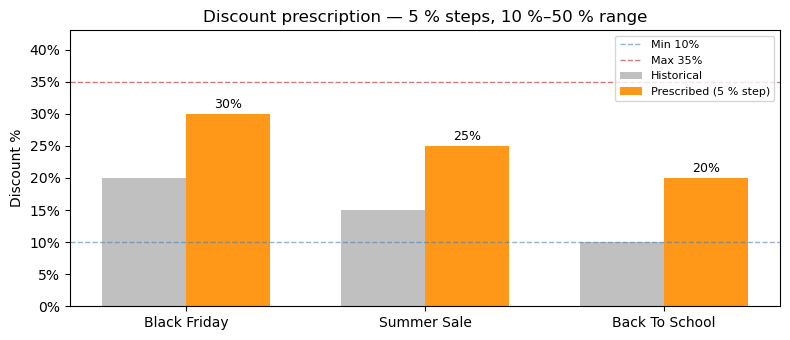

In [39]:
event_names_list = [r["event"] for r in rows]
hist_pcts_list = [float(ev["discount_pct"]) for _, ev in df_events.iterrows()]
pres_pcts_list = [float(r["prescribed (5 %)"].rstrip("%")) / 100 for r in rows]

x = np.arange(len(event_names_list))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(x - w / 2, hist_pcts_list, w, color="silver", label="Historical")
ax.bar(
    x + w / 2,
    pres_pcts_list,
    w,
    color="darkorange",
    label="Prescribed (5 % step)",
    alpha=0.9,
)

for xi, pct in zip(x + w / 2, pres_pcts_list, strict=False):
    ax.text(xi, pct + 0.005, f"{pct:.0%}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(event_names_list)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylabel("Discount %")
ax.set_title("Discount prescription — 5 % steps, 10 %–50 % range")
ax.set_ylim(0, D_MAX + 0.08)
# Draw bound lines
ax.axhline(D_MIN, color="steelblue", lw=1, ls="--", alpha=0.6, label=f"Min {D_MIN:.0%}")
ax.axhline(D_MAX, color="firebrick", lw=1, ls="--", alpha=0.6, label=f"Max {D_MAX:.0%}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Sample response distribution

Sample the posterior predictive response under the current and optimal
allocations. Both `current` and `optimal` contain media *and* event channels;
`sample_response_distribution` passes them through unchanged.

Sampling: [y]
Sampling: [y]


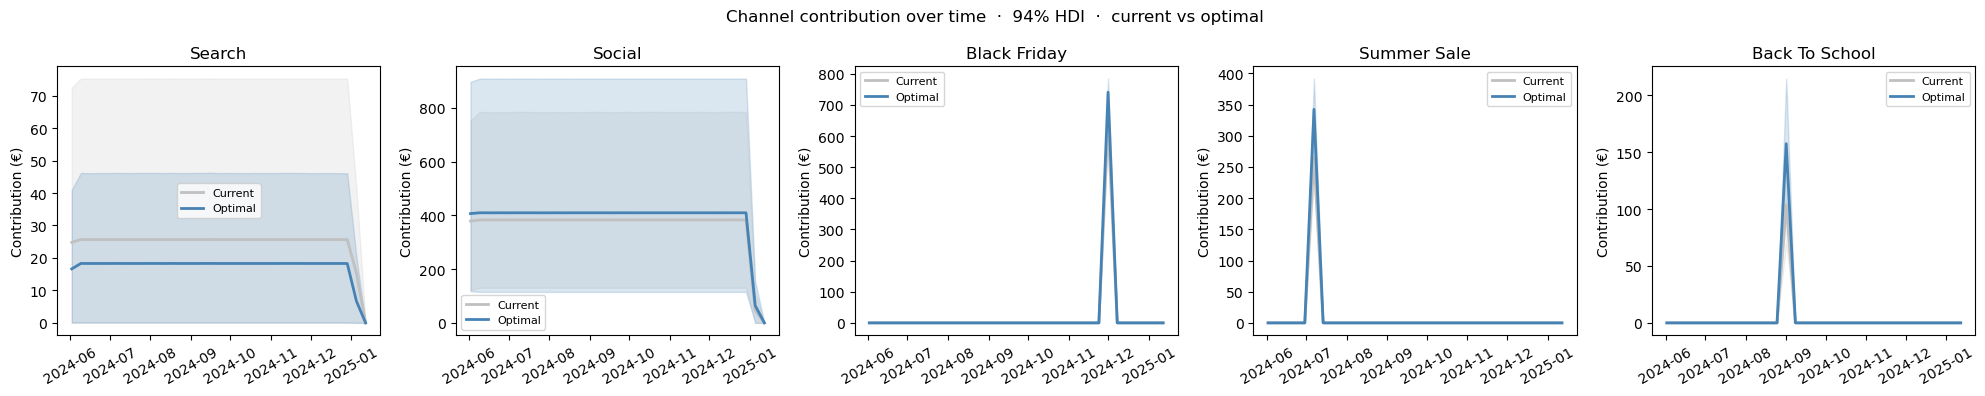

In [40]:
sample_current = wrapper.sample_response_distribution(
    allocation_strategy=current,
    include_carryover=True,
)
sample_optimal = wrapper.sample_response_distribution(
    allocation_strategy=optimal,
    include_carryover=True,
)

dates = sample_current["channel_contribution_original_scale"].coords["date"].values


def _collect_channel_das(cur, opt):
    """Return list of (name, da_current, da_optimal) for every plottable channel."""
    items = []
    # Media channels — tracked in channel_contribution_original_scale (dim: channel)
    for ch in cur["channel_contribution_original_scale"].coords["channel"].values:
        items.append(
            (
                ch,
                cur["channel_contribution_original_scale"].sel(channel=ch),
                opt["channel_contribution_original_scale"].sel(channel=ch),
            )
        )
    # Event channels — tracked in promo_channel_contribution_original_scale (dim: promo)
    ev_var = "promo_channel_contribution_original_scale"
    if ev_var in cur:
        for ev in cur[ev_var].coords["promo"].values:
            items.append(
                (
                    ev,
                    cur[ev_var].sel(promo=ev),
                    opt[ev_var].sel(promo=ev),
                )
            )
    return items


channel_items = _collect_channel_das(sample_current, sample_optimal)

fig, axes = plt.subplots(
    1, len(channel_items), figsize=(4 * len(channel_items), 4), sharey=False
)
axes = np.atleast_1d(axes)

for ax, (ch, da_cur, da_opt) in zip(axes, channel_items, strict=False):
    for da, color, label in [
        (da_cur, "silver", "Current"),
        (da_opt, "steelblue", "Optimal"),
    ]:
        # Transpose to (n_samples, n_dates) before computing statistics
        samples_np = da.transpose("sample", "date").values
        mean = samples_np.mean(axis=0)
        hdi_vals = az.hdi(samples_np, hdi_prob=0.94)  # (n_dates, 2)
        ax.plot(dates, mean, color=color, lw=2, label=label)
        ax.fill_between(dates, hdi_vals[:, 0], hdi_vals[:, 1], color=color, alpha=0.2)
    ax.set_title(ch.replace("_", " ").title())
    ax.set_ylabel("Contribution (€)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

fig.suptitle("Channel contribution over time  ·  94% HDI  ·  current vs optimal")
plt.tight_layout()
plt.show()

## Interpretation

- **Paid media channels** (search, social) are allocated according to the posterior
  response curves from the fitted MMM.
- **Promotional events** receive discount budgets determined by the posterior
  $\beta_k$, the baseline per-period revenue $r_k$, and the event revenue at stake.
  The optimal discount depth for each event is where
  $\frac{d}{dd}[\beta_k \cdot \ln(1+d) \cdot (1-d) - d \cdot r_k] = 0$, which
  depends on the **$r_k / \beta_k$** ratio.  Under a shared budget constraint the
  optimizer prioritises events with the highest initial marginal ROI — events with
  large volume-uplift potential relative to their baseline revenue cost receive deeper
  discounts.
- **All channel types share one budget constraint.**  A euro allocated to deepening the
  Black Friday discount is a euro not spent on search — the optimizer finds the
  portfolio that maximises total expected revenue.

This is what `OptimizableMuEffect` enables: arbitrary spend-driven effects that
participate in the same joint optimisation as standard media channels, with a fully
data-driven spend-to-contribution mapping.
